In [1]:
import pandas as pd 
import matplotlib.pyplot  as plt
import numpy as np
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

data=pd.read_csv("diabetes.csv")
print(data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [2]:
print(data.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')


In [3]:
print("\nDataset info")
print(data.info())


Dataset info
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [4]:
print("\nSummary statistics")
print(data.describe())


Summary statistics
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.0000

In [5]:
print("\nMissing values")
print(data.isnull().sum())


Missing values
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


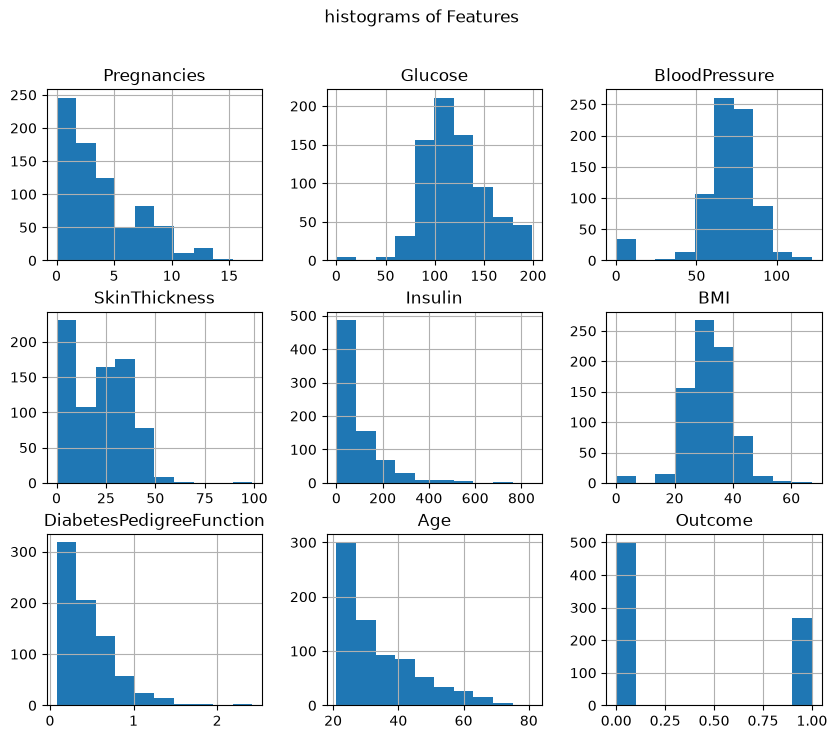

In [6]:
# Visualizations 

# Histogram
data.hist(figsize=(10,8))
plt.suptitle("histograms of Features")
plt.show()

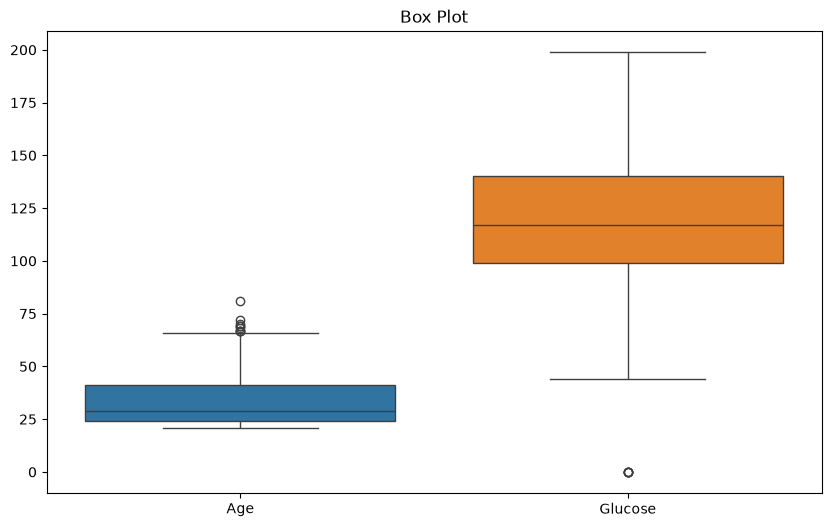

In [7]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data[["Age","Glucose"]])
plt.title("Box Plot")
plt.show()

<Figure size 1000x600 with 0 Axes>

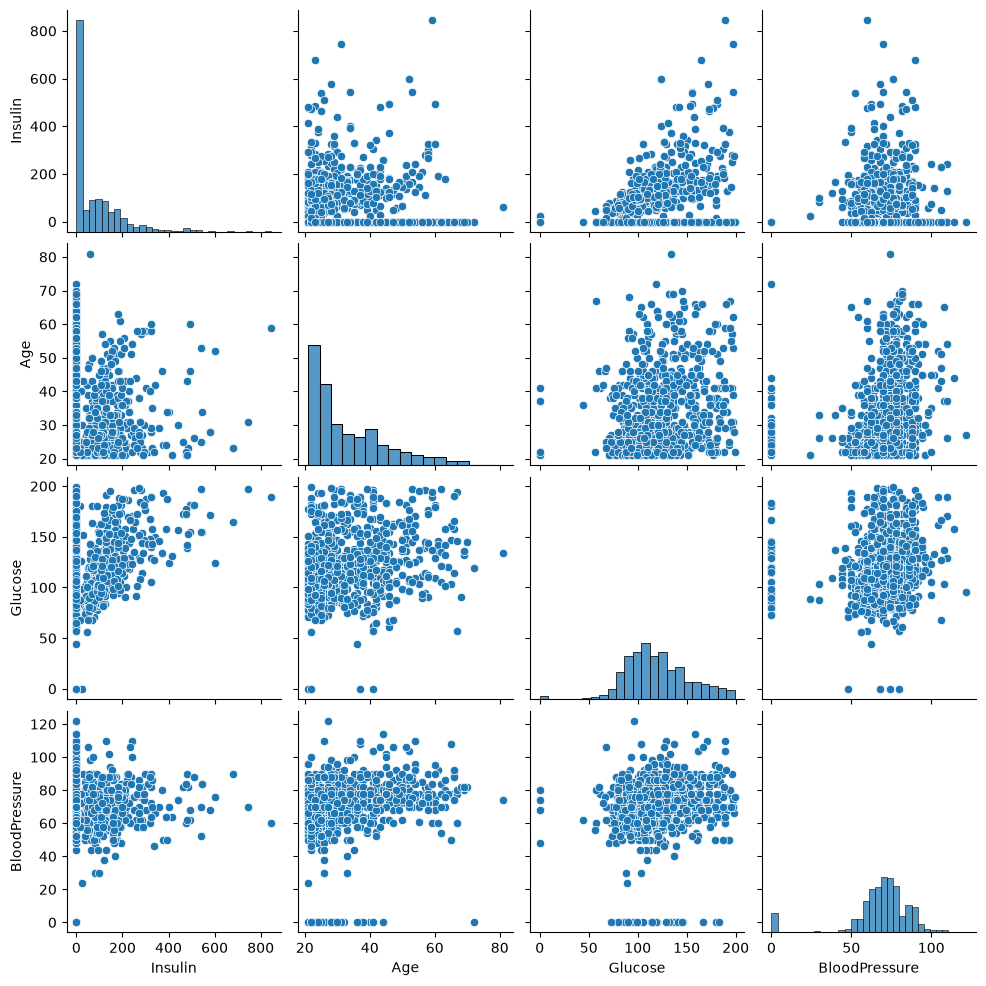

In [8]:
plt.figure(figsize=(10,6))
sns.pairplot(data[["Insulin","Age","Glucose","BloodPressure"]])
plt.show()

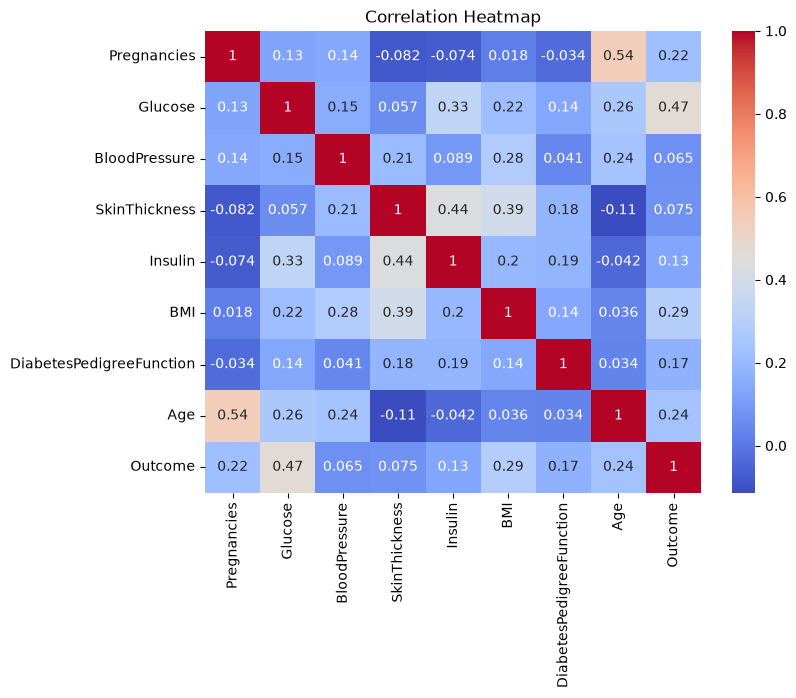

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

data["Age"].fillna(data["Age"].mean())

0      50
1      31
2      32
3      21
4      33
       ..
763    63
764    27
765    30
766    47
767    23
Name: Age, Length: 768, dtype: int64

In [11]:
data["Glucose"].fillna(data["Glucose"].mode()[0])

0      148
1       85
2      183
3       89
4      137
      ... 
763    101
764    122
765    121
766    126
767     93
Name: Glucose, Length: 768, dtype: int64

In [12]:
encoder=LabelEncoder()
data["Age"]=encoder.fit_transform(data["Age"])
print(data["Age"])

0      29
1      10
2      11
3       0
4      12
       ..
763    42
764     6
765     9
766    26
767     2
Name: Age, Length: 768, dtype: int64


In [13]:
data["Glucose"]=encoder.fit_transform(data["Glucose"])
print(data["Glucose"])  

0       86
1       23
2      121
3       27
4       75
      ... 
763     39
764     60
765     59
766     64
767     31
Name: Glucose, Length: 768, dtype: int64


In [14]:
x= data[["Pregnancies","Glucose","Age","BloodPressure","SkinThickness"]]
y=data["Insulin"]
print(x , "\n" , y)

     Pregnancies  Glucose  Age  BloodPressure  SkinThickness
0              6       86   29             72             35
1              1       23   10             66             29
2              8      121   11             64              0
3              1       27    0             66             23
4              0       75   12             40             35
..           ...      ...  ...            ...            ...
763           10       39   42             76             48
764            2       60    6             70             27
765            5       59    9             72             23
766            1       64   26             60              0
767            1       31    2             70             31

[768 rows x 5 columns] 
 0        0
1        0
2        0
3       94
4      168
      ... 
763    180
764      0
765    112
766      0
767      0
Name: Insulin, Length: 768, dtype: int64


In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train,x_test,y_train,y_test)



     Pregnancies  Glucose  Age  BloodPressure  SkinThickness
60             2       22    0              0              0
618            9       50   29             82             24
346            1       77    1             46             19
294            0       99   44             50              0
231            6       72   25             80             37
..           ...      ...  ...            ...            ...
71             5       77    5             64             35
106            1       34    6            122              0
270           10       39   17             86             37
435            0       79    8              0              0
102            0       63    0             96              0

[614 rows x 5 columns]      Pregnancies  Glucose  Age  BloodPressure  SkinThickness
668            6       36   22             58             33
324            2       50    0             75             32
624            2       46    0             64              0


In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score, roc_curve

y_pred=model.predict(x_test)
y_prob=model.predict_proba(x_test)[:1]
print(y_pred)
print("\n",y_prob)

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  83   0   0
   0   0   0   0 114   0   0   0   0   0   0   0  14   0 130 274   0   0
 543   0   0   0   0   0   0   0   0   0 126   0   0 180   0   0   0   0
   0  66   0   0   0   0   0   0   0   0  37 250   0   0   0 194   0   0
   0   0   0   0   0   0   0   0   0   0   0  90   0   0 140   0   0   0
   0   0   0   0   0   0   0   0 291   0 180  37   0   0   0   0   0 130
   0   0   0 185   0 140   0   0 465   0   0   0   0  99 114   0   0 126
   0   0   0   0   0 114   0   0 167   0  51   0   0   0   0   0   0 167
   0   0   0   0   0   0   0   0   0  54]

 [[5.23968234e-01 1.87515178e-09 3.33776885e-06 5.55166524e-03
  1.74862057e-06 4.34356440e-14 1.32089935e-03 1.92733851e-08
  7.32848377e-05 3.73911087e-09 8.43117126e-05 2.63301404e-06
  7.20580833e-05 3.98964559e-04 2.07781214e-05 1.64204368e-04
  2.08563568e-12 4.39529938e-03 1.34430144e-03 2.00883816e-06
  2.71311960e-11 2.99142155e-06 4.21043275e-03 2.50090037e-06


In [18]:


print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='macro', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, average='macro', zero_division=0))
if y_prob.shape[1] == 2:
    print("ROC-AUC:", roc_auc_score(y_test, y_prob[:, 1]))
else:
    print("ROC-AUC: Skip (probability shape mismatch)")


Accuracy: 0.487012987012987
Precision: 0.007792207792207792
Recall: 0.011595547309833025
F1-score: 0.009320822717951904
ROC-AUC: Skip (probability shape mismatch)


In [19]:
fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
plt.plot(fpr, tpr, color='orange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

NameError: name 'X_test' is not defined

In [20]:
coefficients = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_[0]
})

print(coefficients)


         Feature  Coefficient
0    Pregnancies     0.078223
1        Glucose    -0.001440
2            Age     0.255840
3  BloodPressure     0.012009
4  SkinThickness    -0.152851


In [21]:
pickle.dump(model, open("model.pkl", "wb"))


NameError: name 'pickle' is not defined

In [22]:
import streamlit as st
import pandas as pd
import pickle
import joblib

pickle.dump(model, open("model.py", "wb"))

# ------------------------------------
# Load trained model
# ------------------------------------
model = pickle.load(open("model.py", "rb"))

st.title("Titanic Survival Prediction")

# ------------------------------------
# User Inputs
# ------------------------------------
pclass = st.selectbox("Passenger Class", [1, 2, 3])
sex = st.selectbox("Sex", ["Male", "Female"])
age = st.slider("Age", 1, 80, 25)
fare = st.slider("Fare", 0.0, 500.0, 50.0)
embarked = st.selectbox("Embarked", ["S", "C", "Q"])

# Encode inputs
sex = 1 if sex == "Male" else 0
embarked = {"S": 2, "C": 0, "Q": 1}[embarked]

# ------------------------------------
# Prediction
# ------------------------------------
input_data = pd.DataFrame([[pclass, sex, age, fare, embarked]],
                          columns=["Pclass", "Sex", "Age", "Fare", "Embarked"])

if st.button("Predict"):
    result = model.predict(input_data)
    if result[0] == 1:
        st.success("Passenger is likely to SURVIVE")
    else:
        st.error("Passenger is NOT likely to survive")


2026-09-08 22:43:27.809 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-09-08 22:43:27.852 
  command:

    streamlit run /home/vinod/Desktop/Assignments/.venv/lib/python3.12/site-packages/ipykernel_launcher.py [ARGUMENTS]


2026-09-08 22:43:27.853 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-09-08 22:43:27.853 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-09-08 22:43:27.854 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


...

2026-09-08 22:43:27.871 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-09-08 22:43:27.872 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-09-08 22:43:27.872 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-09-08 22:43:27.873 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-09-08 22:43:27.873 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
